____
# Spatial filtering dependency of SWOT


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir,U2, c0
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon, coloc_swot, rotate_ggd, add_grid_metrics
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby


import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

def plot_error(df, x, v, ax, suf = 'ber__'):
    ax.fill_between(
        df[x], df[v] - df[suf + v], df[v] + df[suf + v], color="silver"
    )

___________
# CHOOSE

In [43]:
dt = 2
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5',wd_model='rio', ggd_var='fromduacsv', wd_depth='0')]+[dict(drifter_key='nofilter', alti_key = f'swot2km{int(cutoff)}', wd_key = 'era5',wd_model='rio', ggd_var='etaf', wd_depth='0') for cutoff in np.arange(2000, 13000, 1000)]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True)
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()

df['cutoff'] = [0] + list(np.arange(2000, 13000, 1000))
df = df.reset_index().set_index('cutoff')

nofilter___swot2kmnaive_fromduacsv__rio_0era5
nofilter___swot2km2000_etaf__rio_0era5
nofilter___swot2km3000_etaf__rio_0era5
nofilter___swot2km4000_etaf__rio_0era5
nofilter___swot2km5000_etaf__rio_0era5
nofilter___swot2km6000_etaf__rio_0era5
nofilter___swot2km7000_etaf__rio_0era5
nofilter___swot2km8000_etaf__rio_0era5
nofilter___swot2km9000_etaf__rio_0era5
nofilter___swot2km10000_etaf__rio_0era5
nofilter___swot2km11000_etaf__rio_0era5
nofilter___swot2km12000_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed


In [33]:
dt = 2
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5',wd_model='rio', ggd_var='fromduacsv', wd_depth='0')]+[dict(drifter_key='nofilter', alti_key = f'swot2km{int(cutoff)}', wd_key = 'era5',wd_model='rio', ggd_var='etaf', wd_depth='0') for cutoff in np.arange(2000, 14000, 1000)]
D =[]
for c in comb_list : 
    DS = dataset_coloc_combs([c], nearest =False)
    DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
    DSS = DS.where(DS.depth==0, drop=True)
    D.append(compute_mean_square(DSS)/U2)

ds1 = xr.concat(D, dim = 'id_comb')
df1 = ds1.to_dataframe()

df1['cutoff'] = [0] + list(np.arange(2000, 14000, 1000))
df1 = df1.reset_index().set_index('cutoff')

nofilter___swot2kmnaive_fromduacsv__rio_0era5
Identified SWOT and drifter outliers have been removed
nofilter___swot2km2000_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed
nofilter___swot2km3000_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed
nofilter___swot2km4000_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed
nofilter___swot2km5000_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed
nofilter___swot2km6000_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed
nofilter___swot2km7000_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed
nofilter___swot2km8000_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed
nofilter___swot2km9000_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed
nofilter___swot2km10000_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed
nofilter___swot2km11000_etaf__rio_0era5
Identified S

In [45]:
ds1 = xr.concat(D, dim = 'id_comb')
df1 = ds1.to_dataframe()

In [23]:
comb_list0 = [
             dict(drifter_key='nofilter', alti_key = 'L4withswot', wd_key = 'era5',wd_model='rio', ggd_var='fromduacsv', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotregional', wd_key = 'era5',wd_model='rio', ggd_var='fromduacsv', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotglobal', wd_key = 'era5',wd_model='rio', ggd_var='fromduacsv', wd_depth='0'),
]

DS = dataset_coloc_combs(comb_list0, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DSS0 = DS.where(DS.depth==0, drop=True)

# Closure figs
ds0 = compute_mean_square(DSS0)/U2
df0 = ds0.to_dataframe()


df0['altikey'] = ['L4-SWOT','L4-regional-noSWOT','L4-global-noSWOT']
df0 = df0.reset_index().set_index('altikey')

nofilter___L4withswot_fromduacsv__rio_0era5
nofilter___L4noswotregional_fromduacsv__rio_0era5
nofilter___L4noswotglobal_fromduacsv__rio_0era5
Identified SWOT and drifter outliers have been removed


In [46]:
df0['altikey'] = ['L4-SWOT','L4-regional-noSWOT','L4-global-noSWOT']
df0 = df0.reset_index().set_index('altikey')

ValueError: cannot insert altikey, already exists

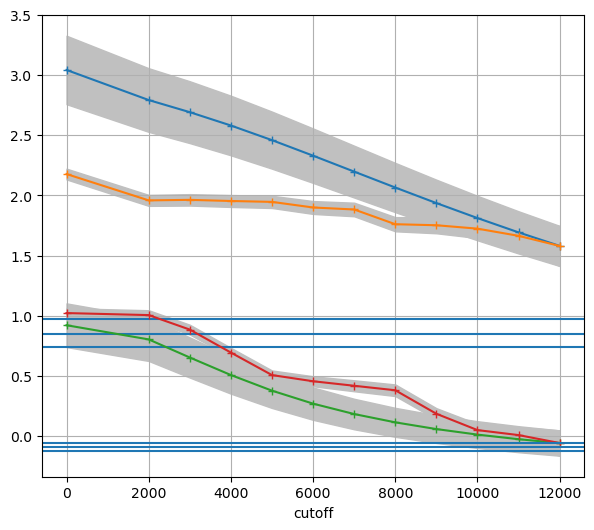

In [50]:

fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
df.B_ggd.plot(marker='+', ax=ax)
plot_error(df.reset_index(),'cutoff', 'B_ggd', ax=ax, suf = 'ser__')

df1.B_ggd.plot(marker='+', ax=ax)
plot_error(df1.reset_index(),'cutoff', 'B_ggd', ax=ax, suf = 'ser__')
#df.E_ggd.plot(marker='+', ax=ax)

for al in df0.index:
    ax.axhline(df0.B_ggd.loc[al])
ax.grid()


df.E_ggd.plot(marker='+', ax=ax)
plot_error(df.reset_index(),'cutoff', 'E_ggd', ax=ax, suf = 'ser__')
#df.E_ggd.plot(marker='+', ax=ax)

df1.E_ggd.plot(marker='+', ax=ax)
plot_error(df1.reset_index(),'cutoff', 'E_ggd', ax=ax, suf = 'ser__')

for al in df0.index:
    ax.axhline(df0.E_ggd.loc[al])
ax.grid()


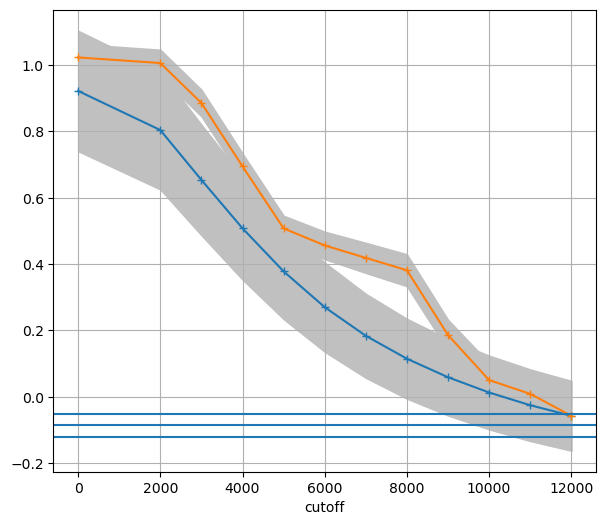

In [49]:

fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
df.E_ggd.plot(marker='+', ax=ax)
plot_error(df.reset_index(),'cutoff', 'E_ggd', ax=ax, suf = 'ser__')
#df.E_ggd.plot(marker='+', ax=ax)

df1.E_ggd.plot(marker='+', ax=ax)
plot_error(df1.reset_index(),'cutoff', 'E_ggd', ax=ax, suf = 'ser__')

for al in df0.index:
    ax.axhline(df0.E_ggd.loc[al])
ax.grid()